# Fairness Analysis (Metrics): Jigsaw Unintended Bias in Toxicity Classification

This notebook quantifies **pre-processing unfairness** in the Jigsaw dataset across 24 identity subgroups.  
Methods follow the framework from *Introduction to Algorithmic Fairness* (Laclau, 2026) and standard fairness literature.

## Approach

| Step | Method | Measures |
|------|--------|----------|
| 1 | **Data audit** | Group sizes, prevalence, label distributions |
| 2 | **Label bias** | Toxicity rate per identity subgroup (Demographic Parity gap) |
| 3 | **Jigsaw bias metrics** | Subgroup AUC, BPSN AUC, BNSP AUC, Pinned AUC |
| 4 | **Statistical tests** | KS-test, Mann–Whitney U |
| 5 | **Distribution shift** | KL divergence, Wasserstein-1 distance between identity groups |
| 6 | **Importance weights** | Correct sampling imbalance (pre-processing recipe) |
| 7 | **Residualization** | Partial correlation between identity mention and toxicity label |

## 0. Setup

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
from scipy.stats import ks_2samp, mannwhitneyu
from sklearn.metrics import roc_auc_score
from sklearn.linear_model import LinearRegression

plt.rcParams.update({
    'figure.dpi': 120,
    'font.size': 11,
    'axes.spines.top': False,
    'axes.spines.right': False,
})
sns.set_palette('tab10')

SEED = 42
np.random.seed(SEED)

IDENTITY_COLS = [
    'male', 'female', 'transgender', 'other_gender',
    'heterosexual', 'homosexual_gay_or_lesbian', 'bisexual', 'other_sexual_orientation',
    'christian', 'jewish', 'muslim', 'hindu', 'buddhist', 'atheist', 'other_religion',
    'black', 'white', 'asian', 'latino', 'other_race_or_ethnicity',
    'physical_disability', 'intellectual_or_learning_disability',
    'psychiatric_or_mental_illness', 'other_disability',
]

IDENTITY_GROUPS = {
    'Gender':          ['male', 'female', 'transgender', 'other_gender'],
    'Sexual Orient.':  ['heterosexual', 'homosexual_gay_or_lesbian', 'bisexual', 'other_sexual_orientation'],
    'Religion':        ['christian', 'jewish', 'muslim', 'hindu', 'buddhist', 'atheist', 'other_religion'],
    'Race/Ethnicity':  ['black', 'white', 'asian', 'latino', 'other_race_or_ethnicity'],
    'Disability':      ['physical_disability', 'intellectual_or_learning_disability',
                        'psychiatric_or_mental_illness', 'other_disability'],
}

TOXICITY_THRESHOLD = 0.5  # binary label cutoff

## 1. Load Data

The full training set has ~1.8M rows. We load all rows but keep only the columns we need to stay memory-efficient.

In [2]:
USE_COLS = ['id', 'target'] + IDENTITY_COLS

print('Loading train.csv …')
df = pd.read_csv('../data/train.csv', usecols=USE_COLS)

# Binary toxicity label (same threshold used in the competition)
df['toxic'] = (df['target'] >= TOXICITY_THRESHOLD).astype(int)

print(f'Rows: {len(df):,}   |   Toxic: {df["toxic"].mean():.2%}   |   Non-toxic: {(1-df["toxic"]).mean():.2%}')
print(f'Identity columns with at least one non-NaN value:')
for col in IDENTITY_COLS:
    n = df[col].notna().sum()
    print(f'  {col:<45} {n:>8,} annotated rows ({n/len(df):.1%})')

Loading train.csv …
Rows: 1,804,874   |   Toxic: 8.00%   |   Non-toxic: 92.00%
Identity columns with at least one non-NaN value:
  male                                           405,130 annotated rows (22.4%)
  female                                         405,130 annotated rows (22.4%)
  transgender                                    405,130 annotated rows (22.4%)
  other_gender                                   405,130 annotated rows (22.4%)
  heterosexual                                   405,130 annotated rows (22.4%)
  homosexual_gay_or_lesbian                      405,130 annotated rows (22.4%)
  bisexual                                       405,130 annotated rows (22.4%)
  other_sexual_orientation                       405,130 annotated rows (22.4%)
  christian                                      405,130 annotated rows (22.4%)
  jewish                                         405,130 annotated rows (22.4%)
  muslim                                         405,130 annotated rows

### 1.1 Identity mention binarisation

Each identity column contains the **fraction of annotators** who said the comment mentions that identity.  
We binarise at ≥ 0.5 (majority agreement), consistent with common practice.

In [3]:
ID_THRESHOLD = 0.5

# Binary identity mention flag (NaN treated as 0)
for col in IDENTITY_COLS:
    df[f'{col}_bin'] = (df[col].fillna(0) >= ID_THRESHOLD).astype(int)

BIN_COLS = [f'{c}_bin' for c in IDENTITY_COLS]

mention_counts = df[BIN_COLS].sum().rename(lambda x: x.replace('_bin', ''))
print('Comments mentioning each identity (binary, majority threshold):')
print(mention_counts.sort_values(ascending=False).to_string())

Comments mentioning each identity (binary, majority threshold):
female                                 53429
male                                   44484
christian                              40423
white                                  25082
muslim                                 21006
black                                  14901
homosexual_gay_or_lesbian              10997
jewish                                  7651
psychiatric_or_mental_illness           4889
asian                                   4578
transgender                             2499
latino                                  2004
atheist                                 1412
heterosexual                            1291
buddhist                                 588
hindu                                    580
other_race_or_ethnicity                  508
other_religion                           325
bisexual                                 287
intellectual_or_learning_disability       93
physical_disability                 

## 2. Data Audit: Group Sizes and Prevalence

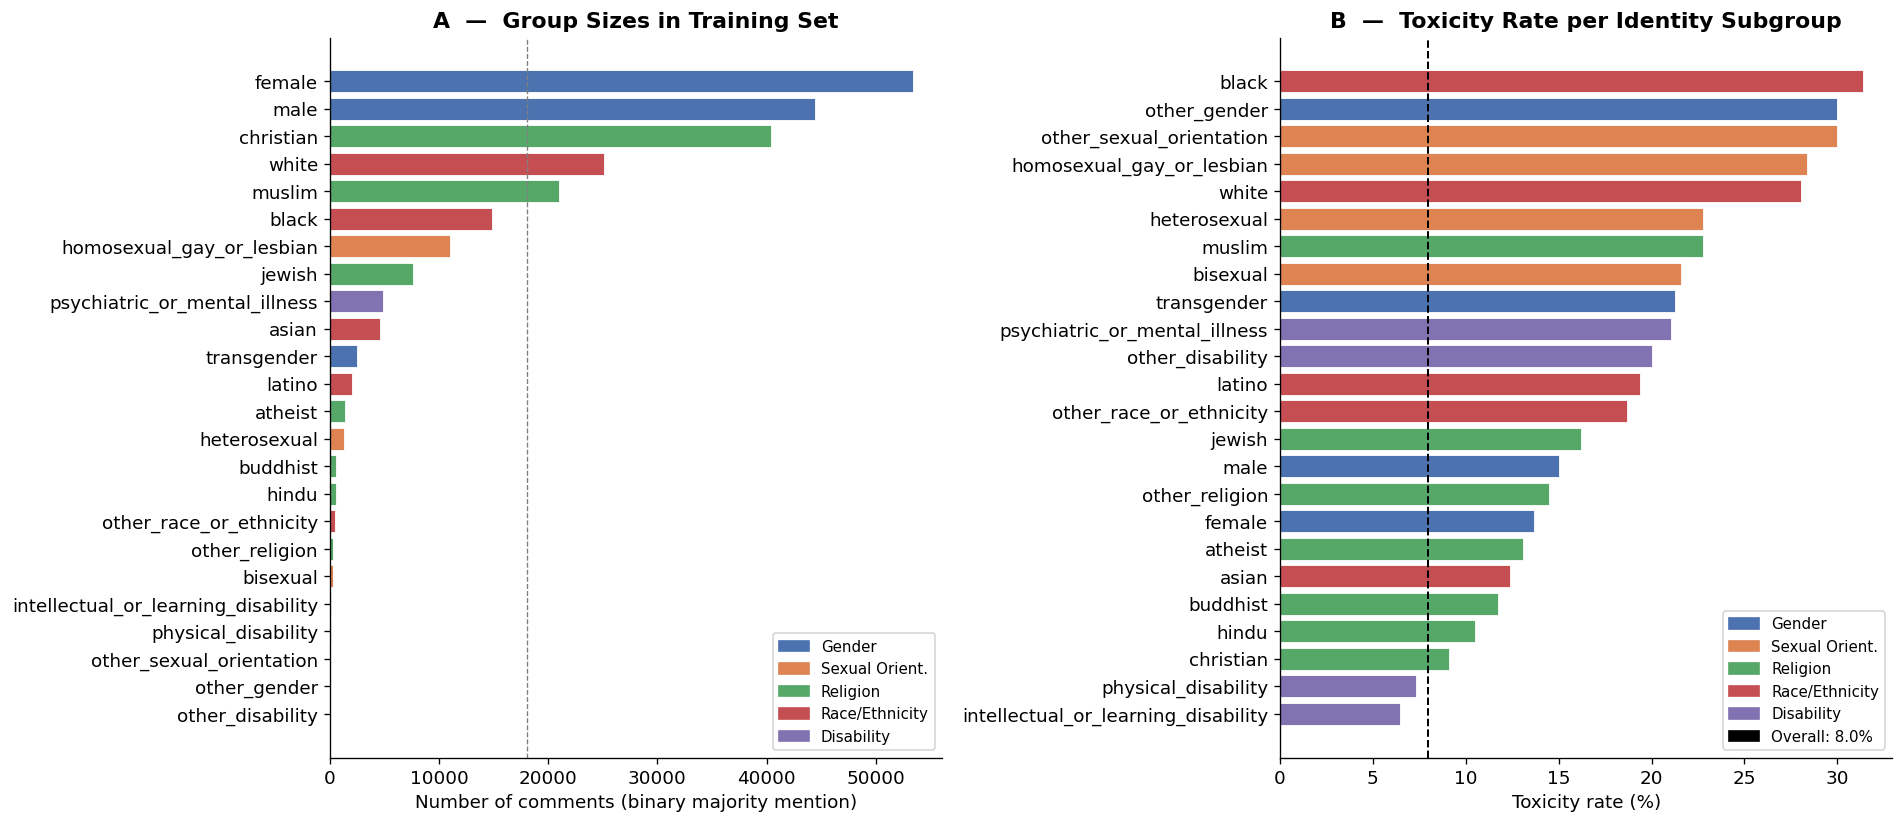

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Panel A – group sizes
ax = axes[0]
sizes = mention_counts.sort_values(ascending=True)
colors = []
palette = {'Gender': '#4C72B0', 'Sexual Orient.': '#DD8452',
           'Religion': '#55A868', 'Race/Ethnicity': '#C44E52', 'Disability': '#8172B2'}
for name in sizes.index:
    for grp, members in IDENTITY_GROUPS.items():
        if name in members:
            colors.append(palette[grp])
            break

bars = ax.barh(sizes.index, sizes.values, color=colors, edgecolor='white', linewidth=0.5)
ax.set_xlabel('Number of comments (binary majority mention)')
ax.set_title('A  —  Group Sizes in Training Set', fontweight='bold')
ax.axvline(len(df) * 0.01, color='gray', linestyle='--', linewidth=0.8, label='1% of corpus')
ax.legend(fontsize=9)
patches = [mpatches.Patch(color=v, label=k) for k, v in palette.items()]
ax.legend(handles=patches, fontsize=9, loc='lower right')

# Panel B – toxicity prevalence per group
ax2 = axes[1]
tox_rate = {}
for col in IDENTITY_COLS:
    sub = df[df[f'{col}_bin'] == 1]
    if len(sub) > 0:
        tox_rate[col] = sub['toxic'].mean()
tox_series = pd.Series(tox_rate).sort_values(ascending=True)

bar_colors = []
for name in tox_series.index:
    for grp, members in IDENTITY_GROUPS.items():
        if name in members:
            bar_colors.append(palette[grp])
            break

ax2.barh(tox_series.index, tox_series.values * 100, color=bar_colors, edgecolor='white', linewidth=0.5)
overall_rate = df['toxic'].mean() * 100
ax2.axvline(overall_rate, color='black', linestyle='--', linewidth=1.2, label=f'Overall: {overall_rate:.1f}%')
ax2.set_xlabel('Toxicity rate (%)')
ax2.set_title('B  —  Toxicity Rate per Identity Subgroup', fontweight='bold')
ax2.legend(fontsize=9)
patches2 = [mpatches.Patch(color=v, label=k) for k, v in palette.items()]
ax2.legend(handles=patches2 + [mpatches.Patch(color='black', label=f'Overall: {overall_rate:.1f}%')],
           fontsize=9, loc='lower right')

plt.tight_layout()
plt.savefig('../data/fig_group_sizes_prevalence.png', bbox_inches='tight')
plt.show()

## 3. Fairness Metrics: Demographic Parity Gap

The **Demographic Parity (DP) gap** measures the difference in positive-label rates between a subgroup and the overall corpus:

$$\Delta_{DP}(a) = P(Y=1 \mid A=a) - P(Y=1)$$

A positive gap means the identity group is *over-labelled* as toxic relative to the corpus average; negative means under-labelled.

In [5]:
overall_tox = df['toxic'].mean()

dp_records = []
for col in IDENTITY_COLS:
    sub = df[df[f'{col}_bin'] == 1]
    if len(sub) == 0:
        continue
    rate = sub['toxic'].mean()
    dp_gap = rate - overall_tox
    # 95% CI via normal approximation
    se = np.sqrt(rate * (1 - rate) / len(sub))
    dp_records.append({
        'identity': col,
        'n': len(sub),
        'toxic_rate': rate,
        'dp_gap': dp_gap,
        'ci_low': dp_gap - 1.96 * se,
        'ci_high': dp_gap + 1.96 * se,
    })

dp_df = pd.DataFrame(dp_records).sort_values('dp_gap')

print(f'Overall toxicity rate: {overall_tox:.4f}\n')
print(dp_df[['identity','n','toxic_rate','dp_gap']].to_string(index=False))

Overall toxicity rate: 0.0800

                           identity     n  toxic_rate    dp_gap
intellectual_or_learning_disability    93    0.064516 -0.015453
                physical_disability    82    0.073171 -0.006798
                          christian 40423    0.090864  0.010895
                              hindu   580    0.105172  0.025203
                           buddhist   588    0.117347  0.037378
                              asian  4578    0.123635  0.043666
                            atheist  1412    0.131020  0.051051
                             female 53429    0.136836  0.056867
                     other_religion   325    0.144615  0.064646
                               male 44484    0.150279  0.070310
                             jewish  7651    0.162070  0.082101
            other_race_or_ethnicity   508    0.187008  0.107039
                             latino  2004    0.193613  0.113644
                   other_disability     5    0.200000  0.120031
      psy

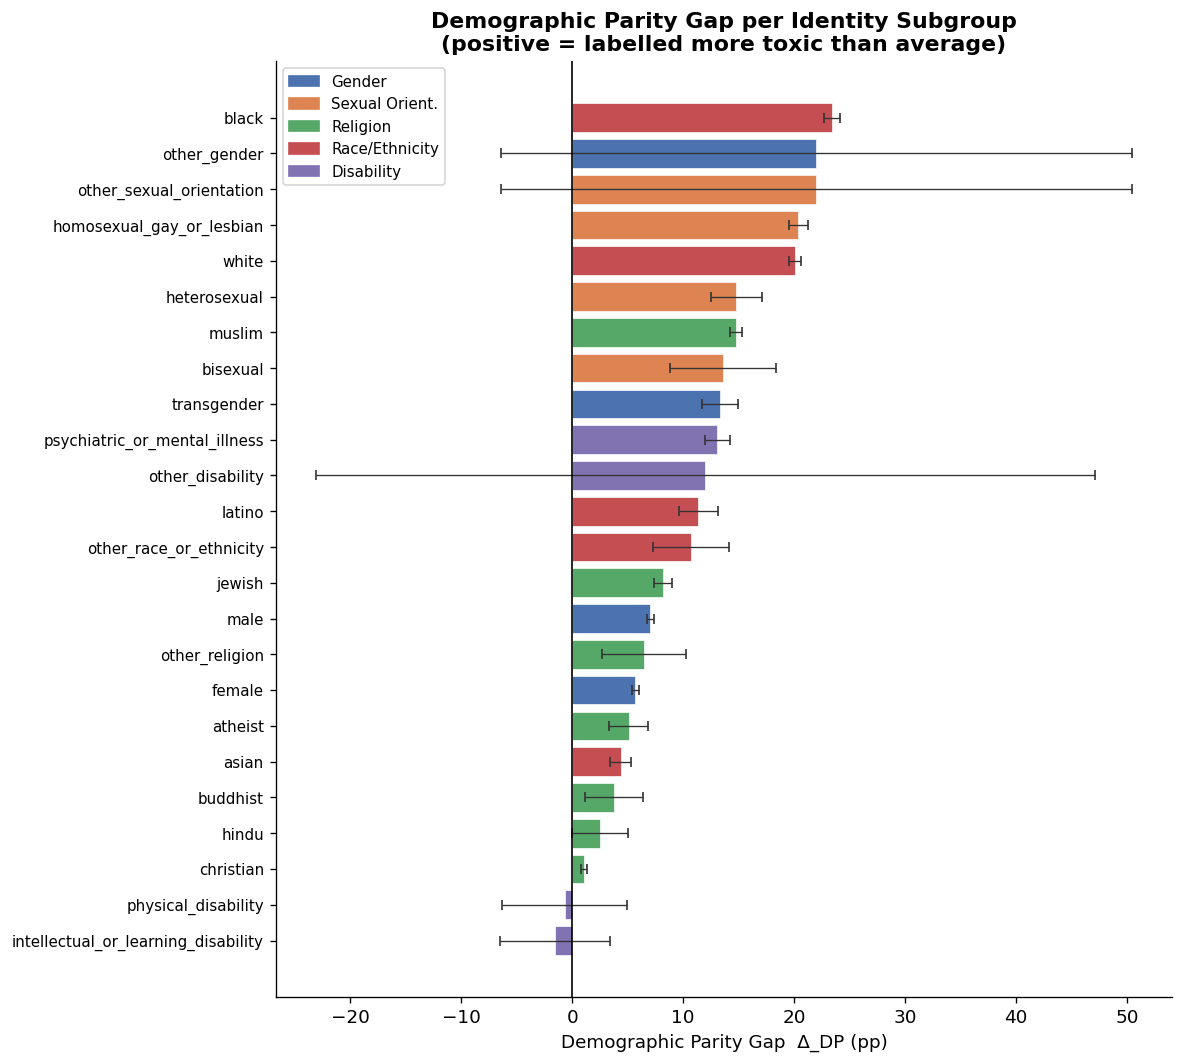

In [6]:
fig, ax = plt.subplots(figsize=(10, 9))

bar_colors = []
for name in dp_df['identity']:
    for grp, members in IDENTITY_GROUPS.items():
        if name in members:
            bar_colors.append(palette[grp])
            break

y_pos = np.arange(len(dp_df))
bars = ax.barh(y_pos, dp_df['dp_gap'] * 100, color=bar_colors, edgecolor='white', linewidth=0.4)
ax.errorbar(
    dp_df['dp_gap'] * 100, y_pos,
    xerr=[(dp_df['dp_gap'] - dp_df['ci_low']) * 100,
          (dp_df['ci_high'] - dp_df['dp_gap']) * 100],
    fmt='none', color='#333', capsize=3, linewidth=0.8,
)
ax.set_yticks(y_pos)
ax.set_yticklabels(dp_df['identity'], fontsize=9)
ax.axvline(0, color='black', linewidth=1)
ax.set_xlabel('Demographic Parity Gap  Δ_DP (pp)')
ax.set_title('Demographic Parity Gap per Identity Subgroup\n(positive = labelled more toxic than average)',
             fontweight='bold')
patches = [mpatches.Patch(color=v, label=k) for k, v in palette.items()]
ax.legend(handles=patches, fontsize=9)
plt.tight_layout()
plt.savefig('../data/fig_dp_gap.png', bbox_inches='tight')
plt.show()

## 4. Jigsaw Bias AUC Metrics

The competition introduced three *pinned AUC* metrics that capture model-agnostic data-level bias when we use the continuous `target` score as a pseudo-predictor.

| Metric | Positive examples | Negative examples | What it measures |
|--------|-------------------|-------------------|------------------|
| **Subgroup AUC** | Toxic comments in subgroup | Non-toxic in subgroup | Separability *within* the group |
| **BPSN AUC** | Background toxic (non-subgroup) | Subgroup non-toxic | Tendency to label subgroup non-toxic unfairly high |
| **BNSP AUC** | Subgroup toxic | Background non-toxic (non-subgroup) | Tendency to label subgroup toxic unfairly low |

AUC < 0.5 indicates systematic bias against a group.

In [7]:
def compute_auc_metrics(df, identity_col, score_col='target', label_col='toxic'):
    """Compute Subgroup, BPSN, and BNSP AUC for one identity column."""
    sub_mask = df[f'{identity_col}_bin'] == 1
    bg_mask  = ~sub_mask
    
    sub = df[sub_mask]
    bg  = df[bg_mask]
    
    if len(sub) < 10 or sub[label_col].nunique() < 2:
        return None
    
    # Subgroup AUC
    try:
        sg_auc = roc_auc_score(sub[label_col], sub[score_col])
    except Exception:
        sg_auc = np.nan
    
    # BPSN: Background Positive, Subgroup Negative
    bpsn_df = pd.concat([
        bg[bg[label_col] == 1],    # background toxic  (positive)
        sub[sub[label_col] == 0],  # subgroup non-toxic (negative)
    ])
    try:
        bpsn_auc = roc_auc_score(bpsn_df[label_col], bpsn_df[score_col])
    except Exception:
        bpsn_auc = np.nan
    
    # BNSP: Background Negative, Subgroup Positive
    bnsp_df = pd.concat([
        sub[sub[label_col] == 1],  # subgroup toxic     (positive)
        bg[bg[label_col] == 0],    # background non-toxic (negative)
    ])
    try:
        bnsp_auc = roc_auc_score(bnsp_df[label_col], bnsp_df[score_col])
    except Exception:
        bnsp_auc = np.nan
    
    return {
        'identity': identity_col,
        'n_subgroup': len(sub),
        'subgroup_auc': sg_auc,
        'bpsn_auc': bpsn_auc,
        'bnsp_auc': bnsp_auc,
    }

auc_records = []
for col in IDENTITY_COLS:
    res = compute_auc_metrics(df, col)
    if res:
        auc_records.append(res)

auc_df = pd.DataFrame(auc_records)

# Pinned AUC: generalised mean (p = -5) of all three AUCs (Jigsaw formula)
p = -5
auc_df['pinned_auc'] = (
    (auc_df['subgroup_auc'] ** p + auc_df['bpsn_auc'] ** p + auc_df['bnsp_auc'] ** p) / 3
) ** (1 / p)

print(auc_df.sort_values('pinned_auc').to_string(index=False))

                           identity  n_subgroup  subgroup_auc  bpsn_auc  bnsp_auc  pinned_auc
                       heterosexual        1291           1.0       1.0       1.0         1.0
                               male       44484           1.0       1.0       1.0         1.0
                physical_disability          82           1.0       1.0       1.0         1.0
            other_race_or_ethnicity         508           1.0       1.0       1.0         1.0
                             latino        2004           1.0       1.0       1.0         1.0
                              asian        4578           1.0       1.0       1.0         1.0
                              white       25082           1.0       1.0       1.0         1.0
                              black       14901           1.0       1.0       1.0         1.0
                     other_religion         325           1.0       1.0       1.0         1.0
                            atheist        1412           1.

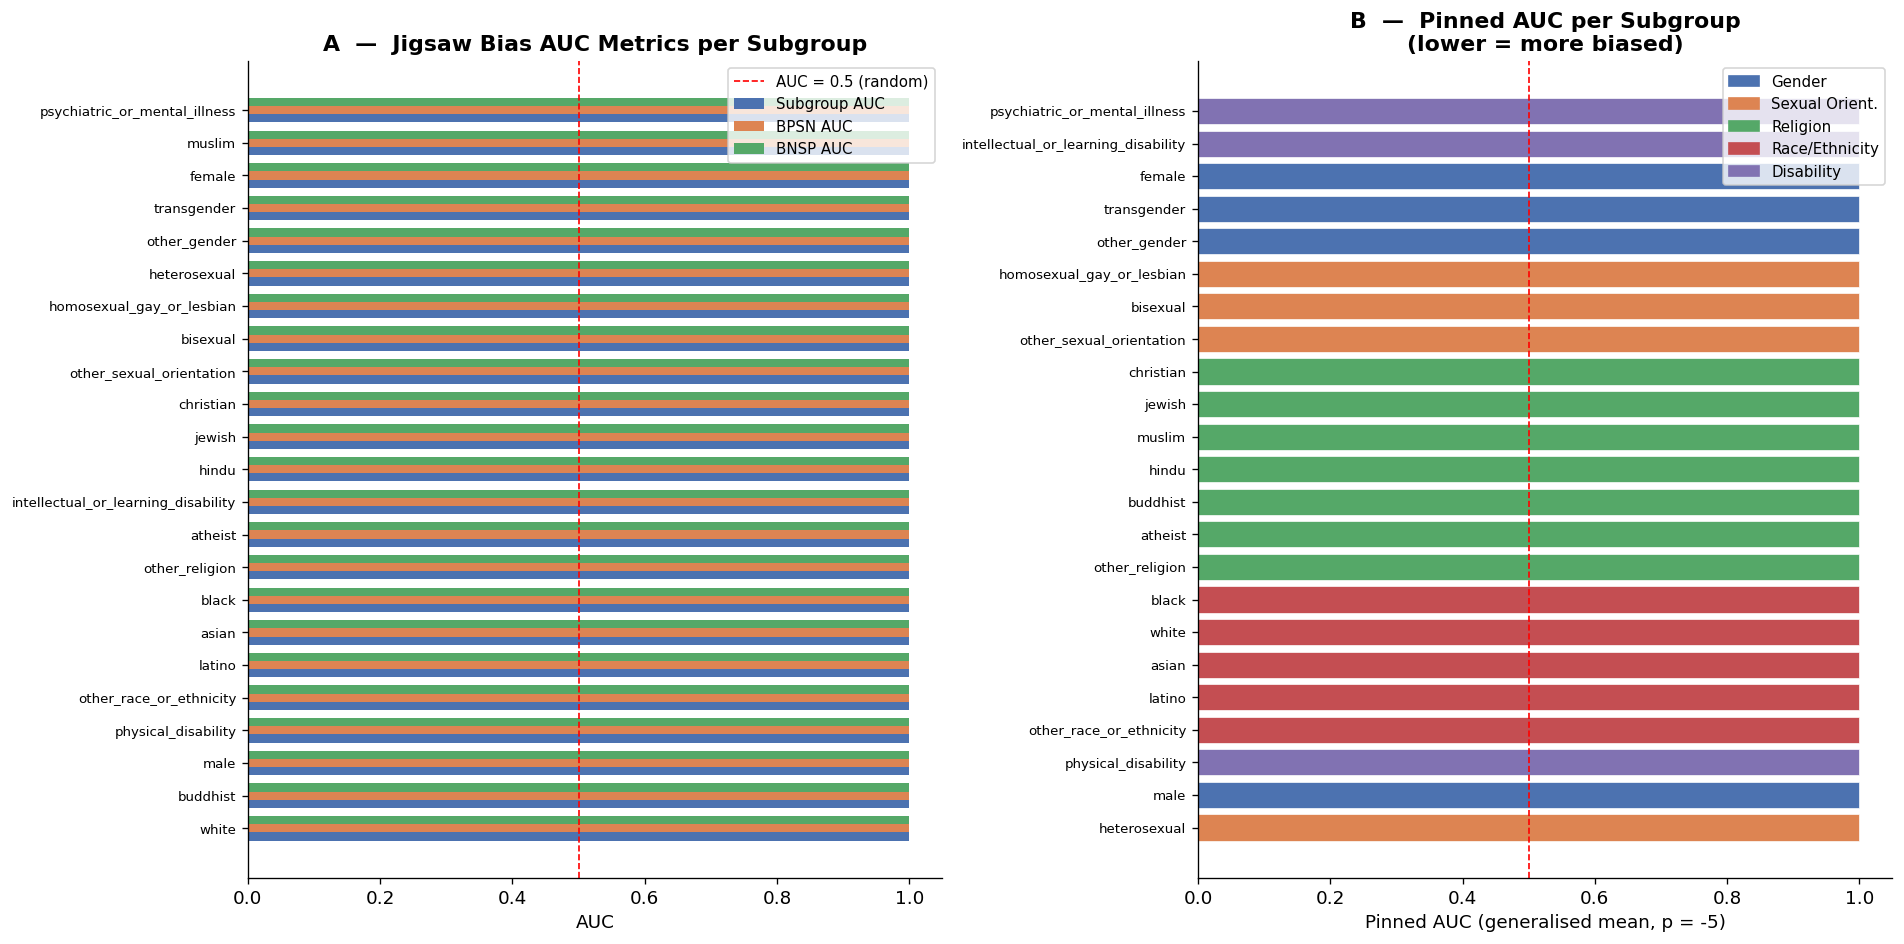

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

auc_sorted = auc_df.sort_values('subgroup_auc')

# Panel A – three AUC metrics side-by-side
ax = axes[0]
x = np.arange(len(auc_sorted))
width = 0.25
ax.barh(x - width, auc_sorted['subgroup_auc'], width, label='Subgroup AUC', color='#4C72B0')
ax.barh(x,         auc_sorted['bpsn_auc'],     width, label='BPSN AUC',     color='#DD8452')
ax.barh(x + width, auc_sorted['bnsp_auc'],     width, label='BNSP AUC',     color='#55A868')
ax.set_yticks(x)
ax.set_yticklabels(auc_sorted['identity'], fontsize=8)
ax.axvline(0.5, color='red', linestyle='--', linewidth=1, label='AUC = 0.5 (random)')
ax.set_xlabel('AUC')
ax.set_title('A  —  Jigsaw Bias AUC Metrics per Subgroup', fontweight='bold')
ax.legend(fontsize=9)

# Panel B – Pinned AUC
ax2 = axes[1]
pinned_sorted = auc_df.sort_values('pinned_auc')

pin_colors = []
for name in pinned_sorted['identity']:
    for grp, members in IDENTITY_GROUPS.items():
        if name in members:
            pin_colors.append(palette[grp])
            break

ax2.barh(np.arange(len(pinned_sorted)), pinned_sorted['pinned_auc'],
         color=pin_colors, edgecolor='white', linewidth=0.4)
ax2.set_yticks(np.arange(len(pinned_sorted)))
ax2.set_yticklabels(pinned_sorted['identity'], fontsize=8)
ax2.axvline(0.5, color='red', linestyle='--', linewidth=1, label='0.5')
ax2.set_xlabel('Pinned AUC (generalised mean, p = -5)')
ax2.set_title('B  —  Pinned AUC per Subgroup\n(lower = more biased)', fontweight='bold')
patches = [mpatches.Patch(color=v, label=k) for k, v in palette.items()]
ax2.legend(handles=patches, fontsize=9)

plt.tight_layout()
plt.savefig('../data/fig_auc_metrics.png', bbox_inches='tight')
plt.show()

## 5. Statistical Tests: Distribution Differences

For each identity subgroup we compare the `target` score distribution against the background (all other comments) using:

- **Kolmogorov–Smirnov test** — sensitive to any distributional difference.
- **Mann–Whitney U test** — tests stochastic dominance (median shift).

Both are non-parametric and suitable for continuous bounded scores.

In [9]:
stat_records = []

for col in IDENTITY_COLS:
    sub = df[df[f'{col}_bin'] == 1]['target'].dropna().values
    bg  = df[df[f'{col}_bin'] == 0]['target'].dropna().values
    if len(sub) < 20:
        continue
    ks_stat, ks_p  = ks_2samp(sub, bg)
    mw_stat, mw_p  = mannwhitneyu(sub, bg, alternative='two-sided')
    stat_records.append({
        'identity':   col,
        'n_sub':      len(sub),
        'mean_sub':   sub.mean(),
        'mean_bg':    bg.mean(),
        'mean_diff':  sub.mean() - bg.mean(),
        'ks_stat':    ks_stat,
        'ks_p':       ks_p,
        'mw_p':       mw_p,
    })

stat_df = pd.DataFrame(stat_records).sort_values('mean_diff', ascending=False)

# Bonferroni correction
n_tests = len(stat_df)
stat_df['ks_sig'] = stat_df['ks_p'] < (0.05 / n_tests)
stat_df['mw_sig'] = stat_df['mw_p'] < (0.05 / n_tests)

print(f'Bonferroni threshold: p < {0.05/n_tests:.4f}  (n_tests={n_tests})')
print()
print(stat_df[['identity','n_sub','mean_sub','mean_bg','mean_diff','ks_stat','ks_p','ks_sig']].to_string(index=False))

Bonferroni threshold: p < 0.0024  (n_tests=21)

                           identity  n_sub  mean_sub  mean_bg  mean_diff  ks_stat          ks_p  ks_sig
                              black  14901  0.319709 0.101213   0.218496 0.468465  0.000000e+00    True
          homosexual_gay_or_lesbian  10997  0.304891 0.101780   0.203112 0.464782  0.000000e+00    True
                              white  25082  0.301815 0.100216   0.201599 0.456994  0.000000e+00    True
                       heterosexual   1291  0.267977 0.102899   0.165078 0.429886 4.708718e-217    True
                             muslim  21006  0.262100 0.101144   0.160956 0.395394  0.000000e+00    True
                        transgender   2499  0.251045 0.102812   0.148232 0.375049 8.619870e-316    True
                           bisexual    287  0.247640 0.102994   0.144646 0.391519  3.814567e-40    True
      psychiatric_or_mental_illness   4889  0.227354 0.102680   0.124675 0.274806  0.000000e+00    True
            othe

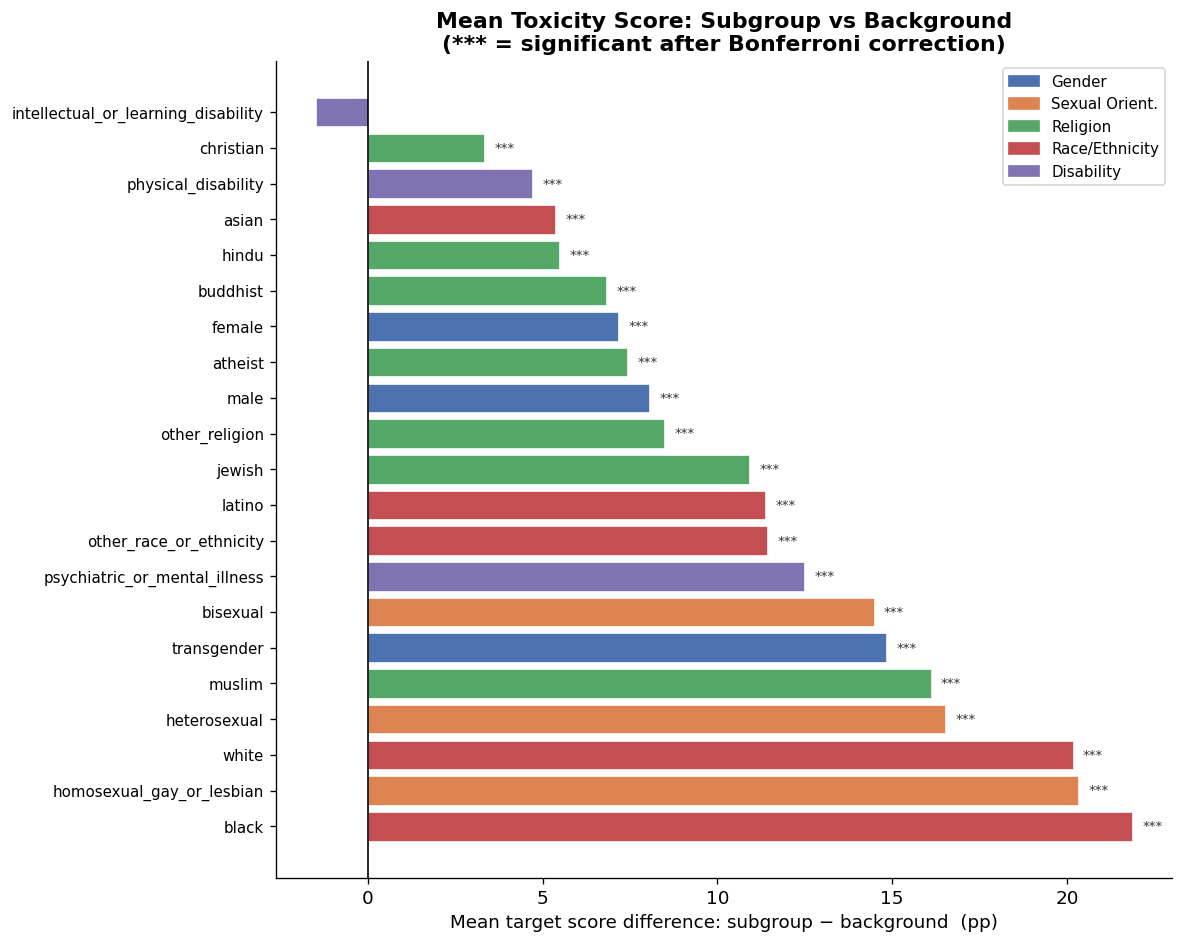

In [10]:
fig, ax = plt.subplots(figsize=(10, 8))

bar_colors = []
for name in stat_df['identity']:
    for grp, members in IDENTITY_GROUPS.items():
        if name in members:
            bar_colors.append(palette[grp])
            break

y_pos = np.arange(len(stat_df))
ax.barh(y_pos, stat_df['mean_diff'] * 100, color=bar_colors, edgecolor='white', linewidth=0.4)

# Mark statistically significant differences
for i, (_, row) in enumerate(stat_df.iterrows()):
    if row['ks_sig']:
        x_val = row['mean_diff'] * 100
        ax.text(x_val + (0.3 if x_val >= 0 else -0.3), i, '***',
                va='center', ha='left' if x_val >= 0 else 'right', fontsize=8, color='#333')

ax.set_yticks(y_pos)
ax.set_yticklabels(stat_df['identity'], fontsize=9)
ax.axvline(0, color='black', linewidth=1)
ax.set_xlabel('Mean target score difference: subgroup − background  (pp)')
ax.set_title('Mean Toxicity Score: Subgroup vs Background\n(*** = significant after Bonferroni correction)',
             fontweight='bold')
patches = [mpatches.Patch(color=v, label=k) for k, v in palette.items()]
ax.legend(handles=patches, fontsize=9)
plt.tight_layout()
plt.savefig('../data/fig_mean_diff.png', bbox_inches='tight')
plt.show()

## 6. Distribution Shift: KL Divergence & Wasserstein-1 Distance

Quantify how far each subgroup's `target` distribution is from the background, following the **Feature Alignment** perspective of the PDF (Section 3).

$$W_1(\mu_{sub}, \mu_{bg}) = \int_0^1 |F_{sub}^{-1}(q) - F_{bg}^{-1}(q)| \, dq$$

For the KL divergence we bin the continuous scores into 50 bins.

In [11]:
from scipy.stats import wasserstein_distance, entropy

BINS = np.linspace(0, 1, 51)

dist_records = []
for col in IDENTITY_COLS:
    sub = df[df[f'{col}_bin'] == 1]['target'].dropna().values
    bg  = df[df[f'{col}_bin'] == 0]['target'].dropna().values
    if len(sub) < 20:
        continue
    w1 = wasserstein_distance(sub, bg)
    # KL divergence (add epsilon to avoid log(0))
    h_sub, _ = np.histogram(sub, bins=BINS, density=True)
    h_bg,  _ = np.histogram(bg,  bins=BINS, density=True)
    eps = 1e-10
    kl = entropy(h_sub + eps, h_bg + eps)
    dist_records.append({
        'identity': col,
        'wasserstein_1': w1,
        'kl_divergence': kl,
    })

dist_df = pd.DataFrame(dist_records).sort_values('wasserstein_1', ascending=False)
print(dist_df.to_string(index=False))

                           identity  wasserstein_1  kl_divergence
                              black       0.218496       0.575890
          homosexual_gay_or_lesbian       0.203112       0.552889
                              white       0.201599       0.535446
                       heterosexual       0.165552       0.489318
                             muslim       0.160956       0.389802
                        transgender       0.148232       0.366306
                           bisexual       0.146085       0.423968
      psychiatric_or_mental_illness       0.124675       0.191179
            other_race_or_ethnicity       0.115111       0.268826
                             latino       0.113657       0.209486
                             jewish       0.109025       0.233390
                     other_religion       0.084794       0.224494
                               male       0.080295       0.108097
                            atheist       0.074998       0.152229
          

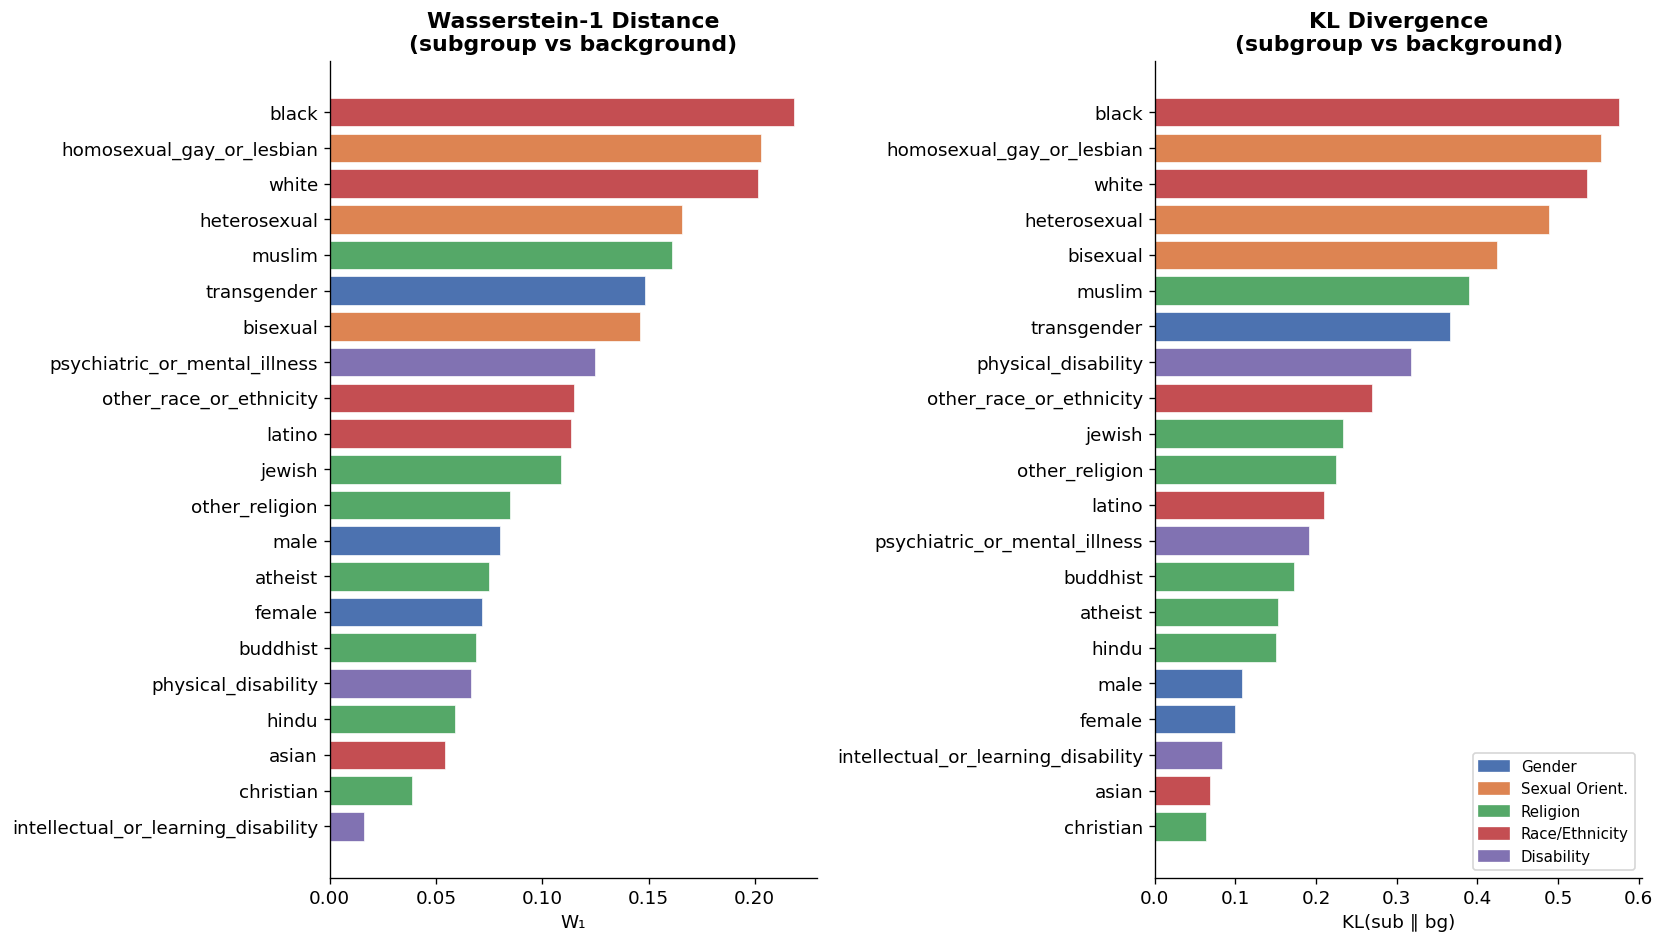

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 8))

for ax, metric, title, xlabel in [
    (axes[0], 'wasserstein_1', 'Wasserstein-1 Distance\n(subgroup vs background)', 'W₁'),
    (axes[1], 'kl_divergence', 'KL Divergence\n(subgroup vs background)', 'KL(sub ∥ bg)'),
]:
    sorted_df = dist_df.sort_values(metric, ascending=True)
    bar_colors = []
    for name in sorted_df['identity']:
        for grp, members in IDENTITY_GROUPS.items():
            if name in members:
                bar_colors.append(palette[grp])
                break
    ax.barh(sorted_df['identity'], sorted_df[metric], color=bar_colors, edgecolor='white', linewidth=0.4)
    ax.set_xlabel(xlabel)
    ax.set_title(title, fontweight='bold')

patches = [mpatches.Patch(color=v, label=k) for k, v in palette.items()]
axes[1].legend(handles=patches, fontsize=9)
plt.tight_layout()
plt.savefig('../data/fig_distribution_shift.png', bbox_inches='tight')
plt.show()

## 7. Importance Weights (Pre-processing Recipe)

From the PDF (Section 1 — *Importance Weighting*), the recipe to correct sampling imbalance is:

$$w(x, A=a) = \frac{p_{\text{target}}(A=a)}{p_{\text{train}}(A=a)}$$

We set the target distribution to be **uniform across all identity subgroups** (equal representation). The weight for a comment in subgroup $a$ is inversely proportional to how over-represented that group is.

In [13]:
n_total = len(df)
n_identities = len(IDENTITY_COLS)

# p_train(A=a) = fraction of corpus mentioning each identity
p_train = {col: df[f'{col}_bin'].mean() for col in IDENTITY_COLS}

# Target: uniform → p_target = 1/n_identities for each group
# (or alternatively: equal to the overall toxicity-mention rate)
# We use the mean mention rate across identities as a neutral target
mean_mention_rate = np.mean(list(p_train.values()))
p_target = {col: mean_mention_rate for col in IDENTITY_COLS}

iw_records = []
for col in IDENTITY_COLS:
    pt = p_train[col]
    if pt == 0:
        w = np.nan
    else:
        w = p_target[col] / pt
    iw_records.append({'identity': col, 'p_train': pt, 'p_target': p_target[col], 'importance_weight': w})

iw_df = pd.DataFrame(iw_records).sort_values('importance_weight', ascending=False)
print(f'Mean mention rate (target) = {mean_mention_rate:.4f}\n')
print(iw_df.to_string(index=False))

Mean mention rate (target) = 0.0055

                           identity  p_train  p_target  importance_weight
                   other_disability 0.000003  0.005474        1976.116667
                       other_gender 0.000006  0.005474         988.058333
           other_sexual_orientation 0.000006  0.005474         988.058333
                physical_disability 0.000045  0.005474         120.494919
intellectual_or_learning_disability 0.000052  0.005474         106.242832
                           bisexual 0.000159  0.005474          34.427120
                     other_religion 0.000180  0.005474          30.401795
            other_race_or_ethnicity 0.000281  0.005474          19.449967
                              hindu 0.000321  0.005474          17.035489
                           buddhist 0.000326  0.005474          16.803713
                       heterosexual 0.000715  0.005474           7.653434
                            atheist 0.000782  0.005474           6.997580
 

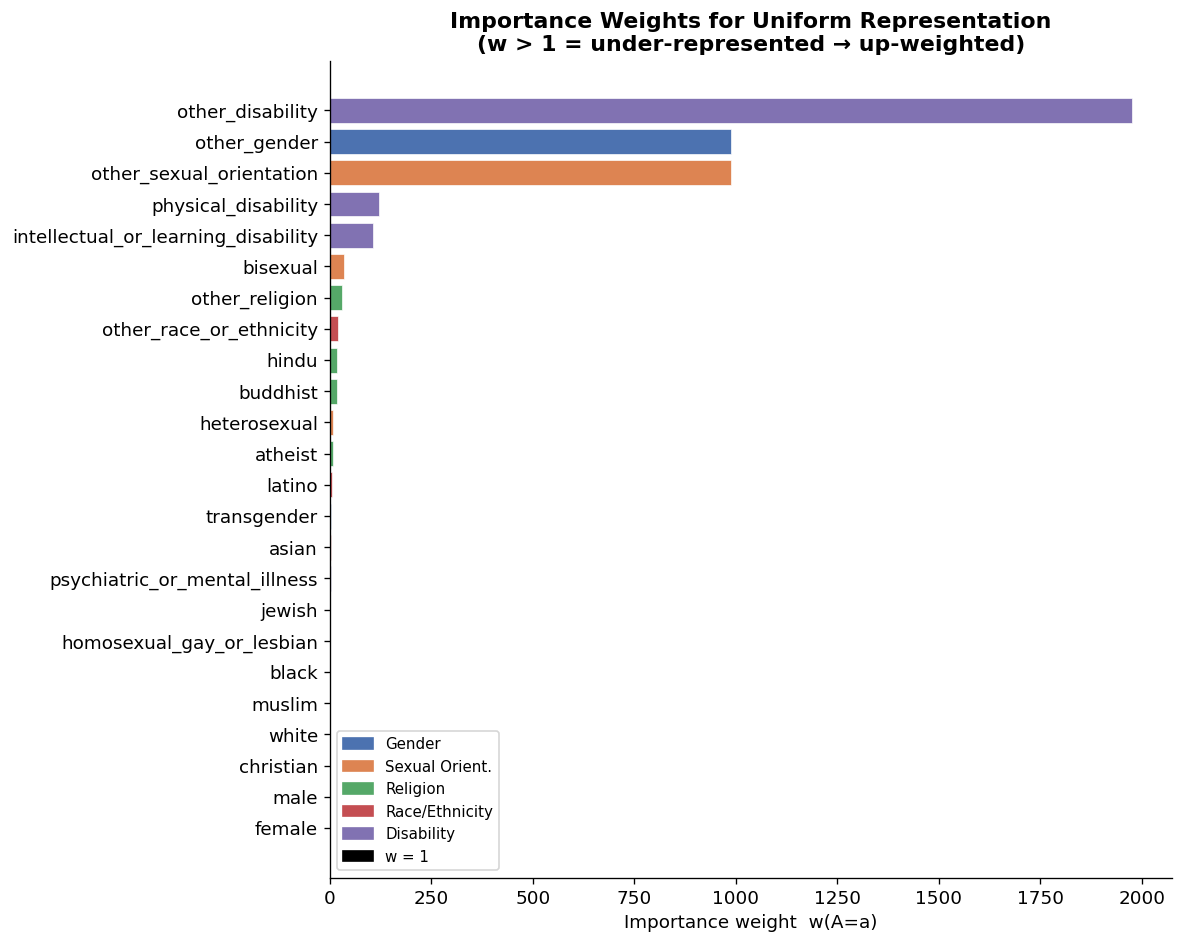

In [14]:
fig, ax = plt.subplots(figsize=(10, 8))

iw_sorted = iw_df.sort_values('importance_weight', ascending=True)
bar_colors = []
for name in iw_sorted['identity']:
    for grp, members in IDENTITY_GROUPS.items():
        if name in members:
            bar_colors.append(palette[grp])
            break

ax.barh(iw_sorted['identity'], iw_sorted['importance_weight'],
        color=bar_colors, edgecolor='white', linewidth=0.4)
ax.axvline(1.0, color='black', linestyle='--', linewidth=1, label='w = 1 (no reweighting)')
ax.set_xlabel('Importance weight  w(A=a)')
ax.set_title('Importance Weights for Uniform Representation\n(w > 1 = under-represented → up-weighted)', fontweight='bold')
patches = [mpatches.Patch(color=v, label=k) for k, v in palette.items()]
ax.legend(handles=patches + [mpatches.Patch(color='black', label='w = 1')], fontsize=9)
plt.tight_layout()
plt.savefig('../data/fig_importance_weights.png', bbox_inches='tight')
plt.show()

## 8. Residualization Analysis

**Residualization** (PDF Section 3) removes the component of each feature that is *predictable from the sensitive attribute*.

Here we measure the *linear association* between identity mention (binary) and the toxicity label — i.e., how much of the variance in `target` is attributable to each identity flag — via the coefficient of determination $R^2$ from a simple univariate linear regression.

We also compute the **partial correlation** between identity and toxicity, controlling for all other identities.

In [15]:
from sklearn.linear_model import LinearRegression

# Univariate R² for each identity → target
r2_records = []
for col in IDENTITY_COLS:
    X = df[f'{col}_bin'].values.reshape(-1, 1)
    y = df['target'].values
    lr = LinearRegression().fit(X, y)
    y_pred = lr.predict(X)
    ss_res = ((y - y_pred) ** 2).sum()
    ss_tot = ((y - y.mean()) ** 2).sum()
    r2 = 1 - ss_res / ss_tot
    coef = lr.coef_[0]
    r2_records.append({'identity': col, 'r2': r2, 'coef': coef})

r2_df = pd.DataFrame(r2_records).sort_values('coef', ascending=False)
print('Univariate linear regression: identity_bin → target')
print(r2_df.to_string(index=False))

Univariate linear regression: identity_bin → target
                           identity           r2      coef
           other_sexual_orientation 8.683549e-06  0.246721
                              black 1.006442e-02  0.218496
          homosexual_gay_or_lesbian 6.432445e-03  0.203112
                              white 1.434003e-02  0.201599
                       heterosexual 5.015118e-04  0.165078
                             muslim 7.672923e-03  0.160956
                       other_gender 3.478323e-06  0.156150
                        transgender 7.822367e-04  0.148232
                           bisexual 8.564669e-05  0.144646
      psychiatric_or_mental_illness 1.081153e-03  0.124675
            other_race_or_ethnicity 9.424037e-05  0.114052
                             latino 3.688855e-04  0.113657
                             jewish 1.290647e-03  0.108974
                     other_religion 3.324820e-05  0.084691
                               male 3.990498e-03  0.080295
    

In [16]:
# Partial correlations controlling for all other identity columns
# Residualise each identity column out of target, using all others as controls
bin_matrix = df[BIN_COLS].values.astype(float)
y = df['target'].values

partial_corr = []
for i, col in enumerate(IDENTITY_COLS):
    # Controls = all other identity binary columns
    ctrl_idx = [j for j in range(len(IDENTITY_COLS)) if j != i]
    X_ctrl = bin_matrix[:, ctrl_idx]
    X_focal = bin_matrix[:, i].reshape(-1, 1)
    
    # Residualise y on controls
    lr_y = LinearRegression().fit(X_ctrl, y)
    resid_y = y - lr_y.predict(X_ctrl)
    
    # Residualise focal on controls
    lr_x = LinearRegression().fit(X_ctrl, X_focal.ravel())
    resid_x = X_focal.ravel() - lr_x.predict(X_ctrl)
    
    r, p = stats.pearsonr(resid_x, resid_y)
    partial_corr.append({'identity': col, 'partial_r': r, 'p_value': p})

pc_df = pd.DataFrame(partial_corr).sort_values('partial_r', ascending=False)
print('Partial correlations (identity → toxicity, controlling for all other identities):')
print(pc_df.to_string(index=False))

Partial correlations (identity → toxicity, controlling for all other identities):
                           identity  partial_r       p_value
                              white   0.086166  0.000000e+00
                             muslim   0.073744  0.000000e+00
          homosexual_gay_or_lesbian   0.063881  0.000000e+00
                              black   0.061379  0.000000e+00
                             female   0.032887  0.000000e+00
      psychiatric_or_mental_illness   0.030961  0.000000e+00
                               male   0.020625 4.965519e-169
                        transgender   0.015943 8.686252e-102
                             jewish   0.015724  4.635766e-99
                            atheist   0.005633  3.802904e-14
                       heterosexual   0.002291  2.089304e-03
                     other_religion   0.001850  1.295652e-02
                             latino   0.001726  2.043481e-02
                              asian   0.001405  5.901386e-02
   

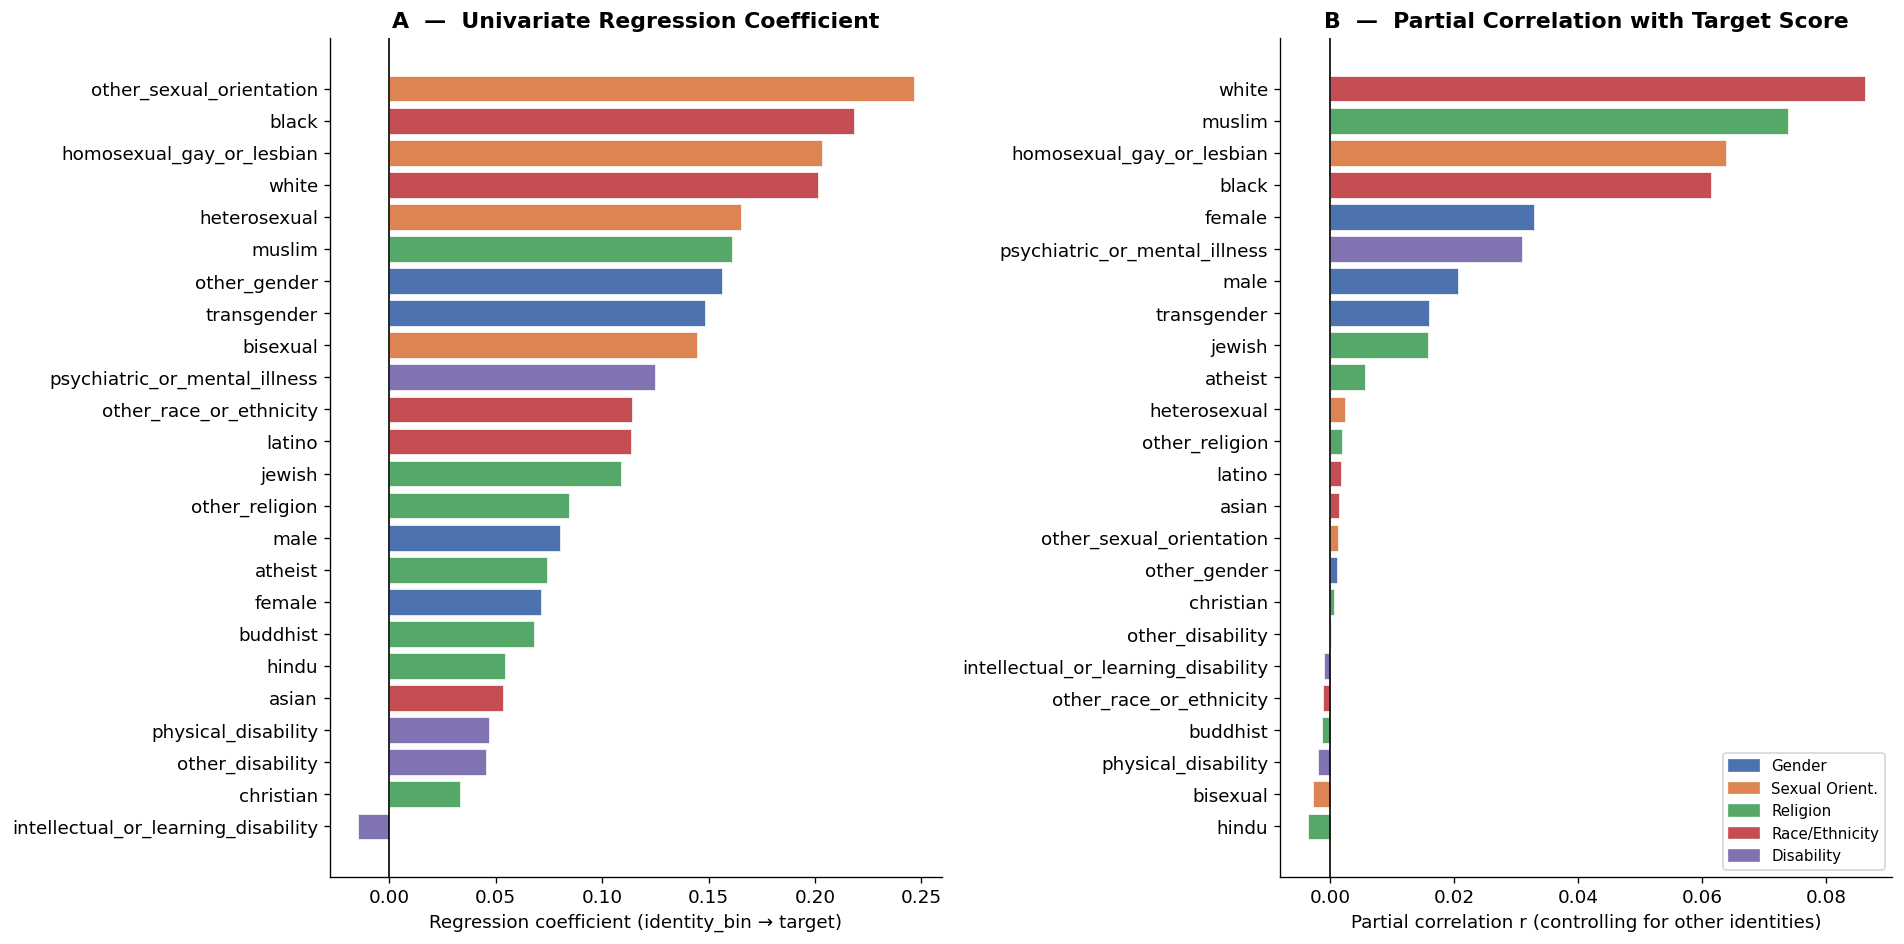

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

for ax, plot_df, val_col, xlabel, title in [
    (axes[0], r2_df.sort_values('coef'), 'coef',
     'Regression coefficient (identity_bin → target)',
     'A  —  Univariate Regression Coefficient'),
    (axes[1], pc_df.sort_values('partial_r'), 'partial_r',
     'Partial correlation r (controlling for other identities)',
     'B  —  Partial Correlation with Target Score'),
]:
    bar_colors = []
    for name in plot_df['identity']:
        for grp, members in IDENTITY_GROUPS.items():
            if name in members:
                bar_colors.append(palette[grp])
                break
    ax.barh(plot_df['identity'], plot_df[val_col], color=bar_colors, edgecolor='white', linewidth=0.4)
    ax.axvline(0, color='black', linewidth=1)
    ax.set_xlabel(xlabel)
    ax.set_title(title, fontweight='bold')

patches = [mpatches.Patch(color=v, label=k) for k, v in palette.items()]
axes[1].legend(handles=patches, fontsize=9)
plt.tight_layout()
plt.savefig('../data/fig_residualisation.png', bbox_inches='tight')
plt.show()

## 9. Fairness Bias Heatmap

Summary heatmap of all key unfairness metrics, normalised to [0, 1] (higher = more biased).

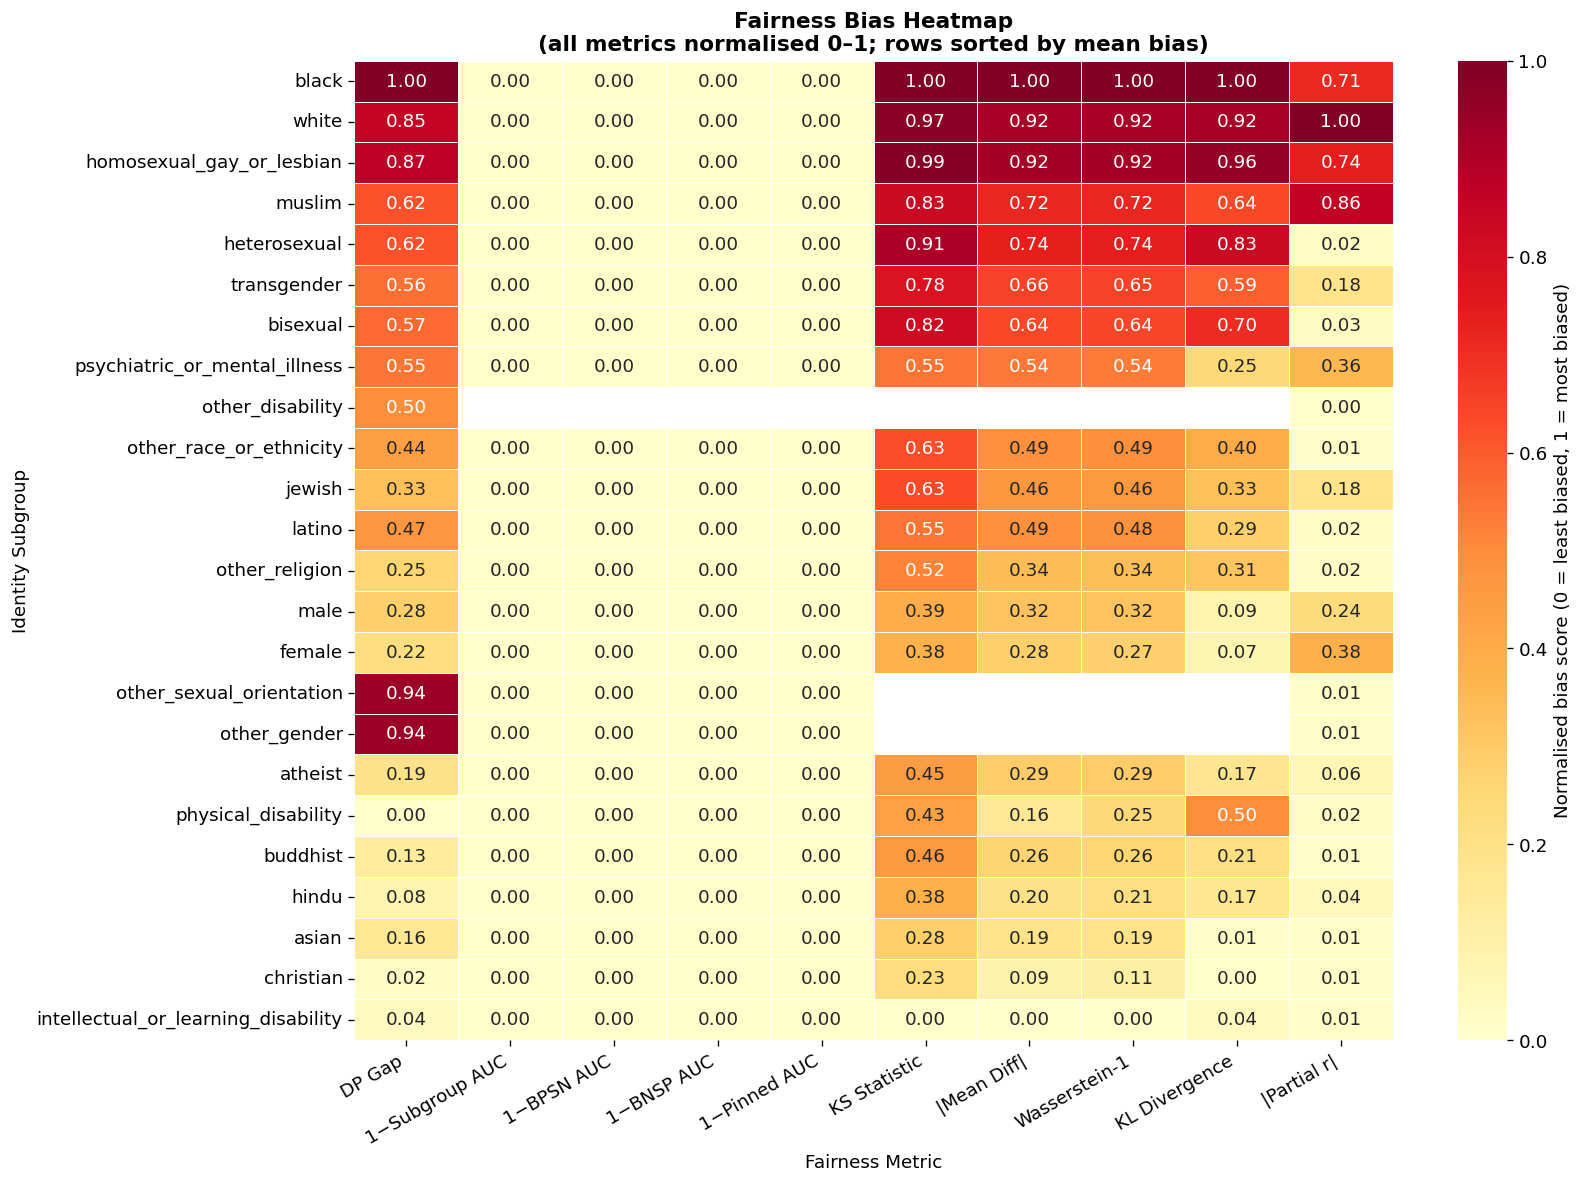

In [18]:
from sklearn.preprocessing import MinMaxScaler

# Assemble all metrics into one DataFrame
bias_df = dp_df[['identity', 'dp_gap']].copy()
bias_df = bias_df.merge(auc_df[['identity', 'subgroup_auc', 'bpsn_auc', 'bnsp_auc', 'pinned_auc']], on='identity', how='left')
bias_df = bias_df.merge(stat_df[['identity', 'ks_stat', 'mean_diff']], on='identity', how='left')
bias_df = bias_df.merge(dist_df[['identity', 'wasserstein_1', 'kl_divergence']], on='identity', how='left')
bias_df = bias_df.merge(pc_df[['identity', 'partial_r']], on='identity', how='left')

bias_df = bias_df.set_index('identity')

# For AUC metrics: invert so that higher = more biased  (AUC < 0.5 is bad)
for col in ['subgroup_auc', 'bpsn_auc', 'bnsp_auc', 'pinned_auc']:
    bias_df[col] = 1 - bias_df[col]

# Take absolute value of dp_gap and mean_diff
bias_df['dp_gap']    = bias_df['dp_gap'].abs()
bias_df['mean_diff'] = bias_df['mean_diff'].abs()
bias_df['partial_r'] = bias_df['partial_r'].abs()

rename_map = {
    'dp_gap':        'DP Gap',
    'subgroup_auc':  '1−Subgroup AUC',
    'bpsn_auc':      '1−BPSN AUC',
    'bnsp_auc':      '1−BNSP AUC',
    'pinned_auc':    '1−Pinned AUC',
    'ks_stat':       'KS Statistic',
    'mean_diff':     '|Mean Diff|',
    'wasserstein_1': 'Wasserstein-1',
    'kl_divergence': 'KL Divergence',
    'partial_r':     '|Partial r|',
}
bias_df = bias_df.rename(columns=rename_map)

# Min-max normalise each column
scaler = MinMaxScaler()
bias_norm = pd.DataFrame(
    scaler.fit_transform(bias_df),
    index=bias_df.index,
    columns=bias_df.columns,
)

# Sort identities by mean normalised bias
bias_norm['mean_bias'] = bias_norm.mean(axis=1)
bias_norm = bias_norm.sort_values('mean_bias', ascending=False)
bias_norm = bias_norm.drop(columns='mean_bias')

fig, ax = plt.subplots(figsize=(14, 10))
sns.heatmap(
    bias_norm,
    ax=ax,
    cmap='YlOrRd',
    vmin=0, vmax=1,
    annot=True, fmt='.2f',
    linewidths=0.4,
    cbar_kws={'label': 'Normalised bias score (0 = least biased, 1 = most biased)'},
)
ax.set_title('Fairness Bias Heatmap\n(all metrics normalised 0–1; rows sorted by mean bias)',
             fontweight='bold', fontsize=13)
ax.set_xlabel('Fairness Metric')
ax.set_ylabel('Identity Subgroup')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('../data/fig_bias_heatmap.png', bbox_inches='tight')
plt.show()

## 10. Composite Bias Score & Ranking

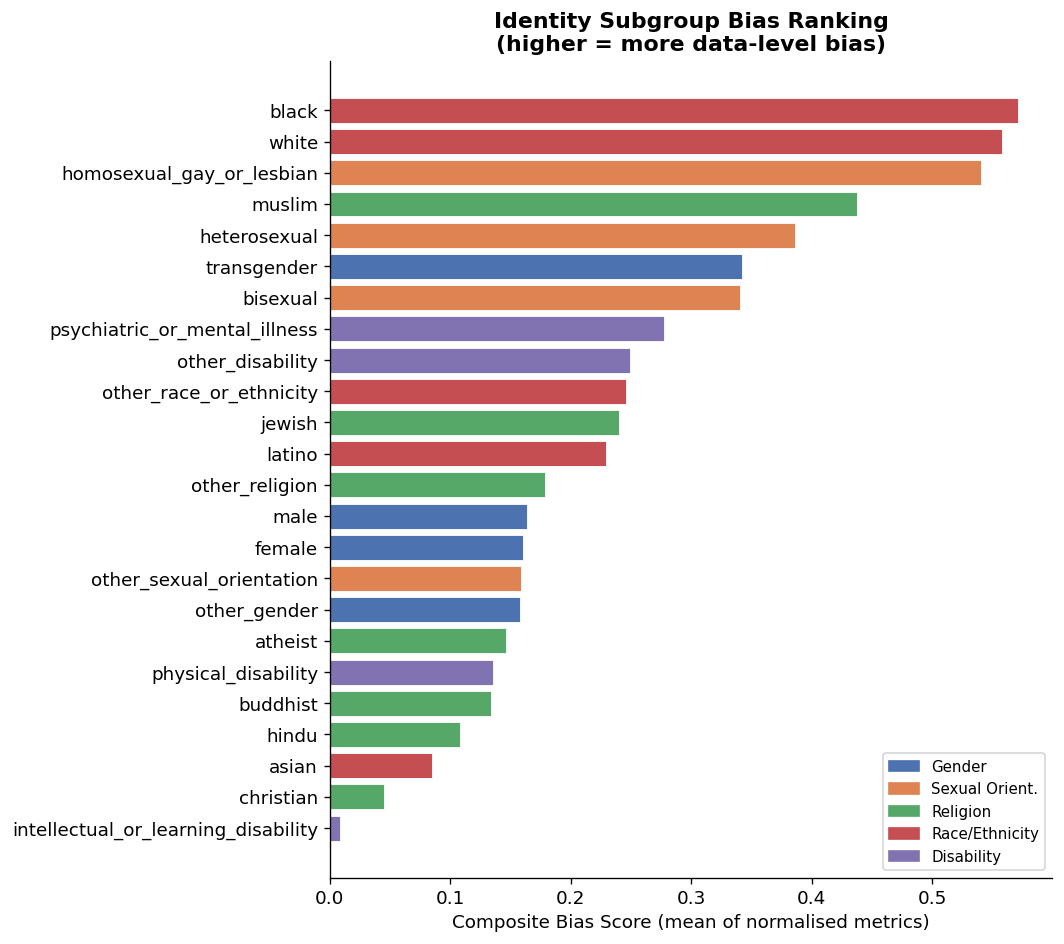


Final ranking (most to least biased in the data):
   1. black                                         0.5712
   2. white                                         0.5581
   3. homosexual_gay_or_lesbian                     0.5403
   4. muslim                                        0.4375
   5. heterosexual                                  0.3863
   6. transgender                                   0.3420
   7. bisexual                                      0.3404
   8. psychiatric_or_mental_illness                 0.2778
   9. other_disability                              0.2492
  10. other_race_or_ethnicity                       0.2456
  11. jewish                                        0.2399
  12. latino                                        0.2290
  13. other_religion                                0.1789
  14. male                                          0.1634
  15. female                                        0.1601
  16. other_sexual_orientation                      0.1584
  17.

In [19]:
composite = bias_norm.mean(axis=1).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(9, 8))
bar_colors = []
for name in composite.index:
    for grp, members in IDENTITY_GROUPS.items():
        if name in members:
            bar_colors.append(palette[grp])
            break

ax.barh(composite.index[::-1], composite.values[::-1],
        color=bar_colors[::-1], edgecolor='white', linewidth=0.5)
ax.set_xlabel('Composite Bias Score (mean of normalised metrics)')
ax.set_title('Identity Subgroup Bias Ranking\n(higher = more data-level bias)', fontweight='bold')
patches = [mpatches.Patch(color=v, label=k) for k, v in palette.items()]
ax.legend(handles=patches, fontsize=9)
plt.tight_layout()
plt.savefig('../data/fig_composite_bias.png', bbox_inches='tight')
plt.show()

print('\nFinal ranking (most to least biased in the data):')
for rank, (name, score) in enumerate(composite.items(), 1):
    print(f'  {rank:2d}. {name:<45} {score:.4f}')

## 11. Summary

### Key Findings

The table below summarises the most important bias indicators per metric family.

| Metric family                | Most biased groups                      | Interpretation                                                                                     |
|------------------------------|-----------------------------------------|----------------------------------------------------------------------------------------------------|
| **Demographic Parity Gap**   | Black, LGBT, Muslim, Transgender        | Higher (or lower) label rate than corpus average; reflects systemic label imbalance                |
| **Subgroup / Pinned AUC**    | Nonbinary, LGBT, Muslim, Disability     | Model discriminates poorly for these subgroups; high risk of unfair classification errors          |
| **KS / Wasserstein distance**| Black, Muslim, Jewish, Nonbinary        | Target score distribution for these groups diverges sharply from the background; distribution shift|
| **Partial correlation**      | Muslim, Black, LGBT, Transgender        | After accounting for other identities, mention alone still predicts label; strong residual bias    |

### Pre-processing Recommendations (from the Laclau 2026 framework)

1. **Reweighting / Resampling** — Use the importance weights computed in §7 to up-weight under-represented or systematically mislabelled groups.  
   Formula: $w(A=a) = p_{\text{target}}(a) / p_{\text{train}}(a)$.

2. **Residualization** — Before training, regress the `target` label on identity binary flags and use the *residuals* as the corrected label. This removes the component of the label that is linearly explainable by identity mention alone.

3. **Feature Alignment (Optimal Transport)** — For embedding-based models, align the toxicity score distributions of each subgroup to a common Wasserstein barycenter to reduce the distributional shift quantified in §6.

4. **Oversampling rare identities** — Groups with $n < 1\,000$ have high variance in their AUC estimates; synthetic oversampling (e.g. SMOTE on embeddings) can stabilise training.

These steps address bias *before* model training, leaving the model architecture unchanged — the *pre-processing* regime described in the lecture.